In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft
import pandas as pd
import time

# 4章演習問題

## (1) 回転因子の性質


(a) $W_N^{k\cdot 2m}=W_{N/2}^{km}$

\begin{align}
W_{N}^{k\cdot 2m} &= \exp\left( -j\frac{2\pi}{N}k\cdot 2m \right) = \exp\left( -j\frac{2\pi}{N/2}km \right) = W_{N/2}^{km}
\end{align}

(b) $W_N^{r+N/2}=-W_{N}^{r}$

\begin{align}
W_{N}^{r+N/2} &= \exp{\left( -j\frac{2\pi}{N}(r+N/2) \right)} = \exp\left( -j\frac{2\pi}{N}r \right)\exp\left( -j\pi \right) = -W_{N}^{r}
\end{align}

## (2) ビット逆順

(a) N=1,2,4,8,16,32のFFTにおけるビット逆順の配置

In [22]:
print("N=1")
print("0" + "\t" + "0" + "\t" + "0")

for N in [2, 4, 8, 16, 32]:
    strN = str(N)
    print("N="+strN)
    nzeros = str(len(bin(N))-2)
    fmt = '{:0' + nzeros + 'b}'
    for i in range(N):
        stri = fmt.format(i)
        nstri = len(stri)
        strinv = ''
        for j in range(nstri-1):
            strinv += stri[nstri-j-1]
        print(stri[1:] + "\t" + strinv + "\t" + str(int(strinv, 2)))
    print("")

N=1
0	0	0
N=2
0	0	0
1	1	1

N=4
00	00	0
01	10	2
10	01	1
11	11	3

N=8
000	000	0
001	100	4
010	010	2
011	110	6
100	001	1
101	101	5
110	011	3
111	111	7

N=16
0000	0000	0
0001	1000	8
0010	0100	4
0011	1100	12
0100	0010	2
0101	1010	10
0110	0110	6
0111	1110	14
1000	0001	1
1001	1001	9
1010	0101	5
1011	1101	13
1100	0011	3
1101	1011	11
1110	0111	7
1111	1111	15

N=32
00000	00000	0
00001	10000	16
00010	01000	8
00011	11000	24
00100	00100	4
00101	10100	20
00110	01100	12
00111	11100	28
01000	00010	2
01001	10010	18
01010	01010	10
01011	11010	26
01100	00110	6
01101	10110	22
01110	01110	14
01111	11110	30
10000	00001	1
10001	10001	17
10010	01001	9
10011	11001	25
10100	00101	5
10101	10101	21
10110	01101	13
10111	11101	29
11000	00011	3
11001	10011	19
11010	01011	11
11011	11011	27
11100	00111	7
11101	10111	23
11110	01111	15
11111	11111	31



(b) 偶数と奇数に再帰的に分ける操作は，(a)２進数の最下位ビットが0（偶数）か1（奇数）かで分け，(b)最下位ビットを捨てる（２で割る），を繰り返す操作で，bit逆順に対応するため．

## (3) FFTの流れ図
ノート

## (4) DFTとFFTの複素乗算回数

     p     N        D       F       F/D
0    0     1        1     0.0  0.000000
1    1     2        4     1.0  0.250000
2    2     4       16     4.0  0.250000
3    3     8       64    12.0  0.187500
4    4    16      256    32.0  0.125000
5    5    32     1024    80.0  0.078125
6    6    64     4096   192.0  0.046875
7    7   128    16384   448.0  0.027344
8    8   256    65536  1024.0  0.015625
9    9   512   262144  2304.0  0.008789
10  10  1024  1048576  5120.0  0.004883


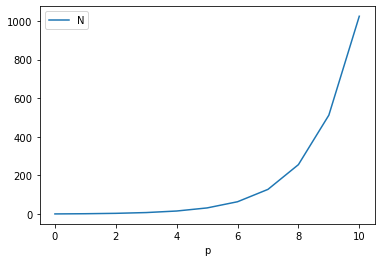

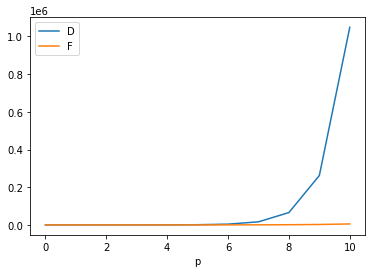

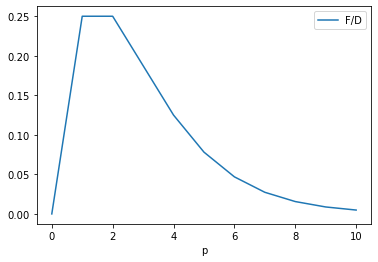

In [10]:
p = np.array([i for i in range(11)])
N = 2**p
D = N**2
F = N/2.0 * np.log2(N)
ratio = F/ D
df = pd.DataFrame({"p": p, "N": N, "D": D, "F":F, "F/D": ratio})
print(df)

df.plot(x="p", y="N")
df.plot(x="p", y=["D", "F"])
df.plot(x="p", y="F/D")

## (5) DFTとFFTの実装

In [4]:
def myDFT(x):
    N = x.size
    W = np.array([np.exp(-1.0j * 2.0 * np.pi / N) ** n for n in range(N)])
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        t = 0.0 + 0.0j
        for n in range(N):
            t += W[(k * n) % N] * x[n]
        X[k] = t
    return X

def myFFT(x):
    N = x.size
    W = np.array([np.exp(-1.0j * 2.0 * np.pi / N) ** n for n in range(N)])
    X = np.array([xi for xi in x], dtype=complex)
    
    # bit inverse
    nv2 = N // 2
    q = 0
    for r in range(1, N-1):
        k = nv2
        while k <= q:
            q = q - k
            k = k // 2
        q = q + k
     
        if r < q:
            tmp = X[q]
            X[q] = X[r]
            X[r] = tmp
        
    # FFT
    p = int(np.log2(N))
    for s in range(1, p+1):
        k1 = 2**s
        k2 = k1 // 2
        Nk1 = N // k1
        for m in range(k2):
            kn = m * Nk1
            for q in range(m, N, k1):
                r = q + k2
                Xtmp = W[kn] * X[r]
                X[r] = X[q] - Xtmp
                X[q] = X[q] + Xtmp
    return X

動作確認　教科書の例題3.2

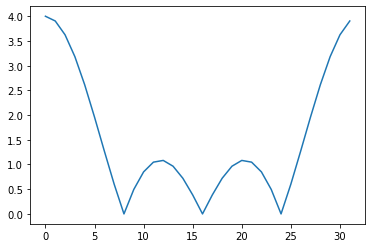

[ 4.00000000e+00+0.00000000e+00j  3.73613443e+00-1.13334399e+00j
  3.01366975e+00-2.01366975e+00j  2.01906272e+00-2.46023505e+00j
  1.00000000e+00-2.41421356e+00j  1.92101520e-01-1.95043947e+00j
 -2.48302881e-01-1.24830288e+00j -2.84359444e-01-5.31999100e-01j
  4.44089210e-16-4.44089210e-16j  4.36600378e-01+2.33367764e-01j
  8.34089319e-01+1.65910681e-01j  1.04253162e+00-1.02680402e-01j
  1.00000000e+00-4.14213562e-01j  7.46304142e-01-6.12475981e-01j
  4.00543816e-01-5.99456184e-01j  1.11624640e-01-3.67977123e-01j
  8.88178420e-16+0.00000000e+00j  1.11624640e-01+3.67977123e-01j
  4.00543816e-01+5.99456184e-01j  7.46304142e-01+6.12475981e-01j
  1.00000000e+00+4.14213562e-01j  1.04253162e+00+1.02680402e-01j
  8.34089319e-01-1.65910681e-01j  4.36600378e-01-2.33367764e-01j
  4.44089210e-16-4.44089210e-16j -2.84359444e-01+5.31999100e-01j
 -2.48302881e-01+1.24830288e+00j  1.92101520e-01+1.95043947e+00j
  1.00000000e+00+2.41421356e+00j  2.01906272e+00+2.46023505e+00j
  3.01366975e+00+2.013669

In [5]:
x = np.zeros(32)
for i in range(x.size):
    if i < 4:
        x[i] = 1.0

#x = np.array([1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0])
X = myDFT(x)
plt.plot(np.abs(X))
plt.show()

print(X)

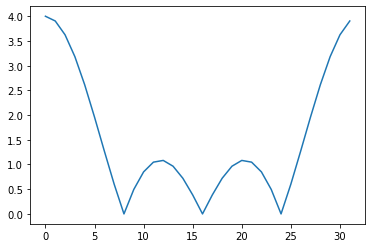

[ 4.        +0.j          3.73613443-1.13334399j  3.01366975-2.01366975j
  2.01906272-2.46023505j  1.        -2.41421356j  0.19210152-1.95043947j
 -0.24830288-1.24830288j -0.28435944-0.5319991j   0.        +0.j
  0.43660038+0.23336776j  0.83408932+0.16591068j  1.04253162-0.1026804j
  1.        -0.41421356j  0.74630414-0.61247598j  0.40054382-0.59945618j
  0.11162464-0.36797712j  0.        +0.j          0.11162464+0.36797712j
  0.40054382+0.59945618j  0.74630414+0.61247598j  1.        +0.41421356j
  1.04253162+0.1026804j   0.83408932-0.16591068j  0.43660038-0.23336776j
  0.        +0.j         -0.28435944+0.5319991j  -0.24830288+1.24830288j
  0.19210152+1.95043947j  1.        +2.41421356j  2.01906272+2.46023505j
  3.01366975+2.01366975j  3.73613443+1.13334399j]


In [6]:
#x = np.array([1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0])
X = myFFT(x)
plt.plot(np.abs(X))
plt.show()

print(X)

処理時間計測

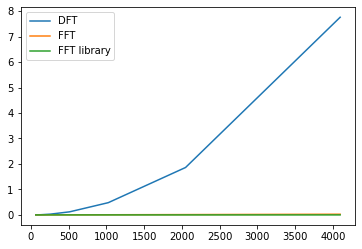

In [7]:
ns = [2**i for i in range(6, 13)]
tdft = []
tfft = []
tfftlib = []
for n in ns:
    x = np.random.rand(n)
    
    ts = time.time()
    X = myDFT(x)
    te = time.time()
    tdft.append(te - ts)
    
    ts = time.time()
    X = myFFT(x)
    te = time.time()
    tfft.append(te - ts)
    
    
    ts = time.time()
    X = np.fft.fft(x)
    te = time.time()
    tfftlib.append(te - ts)

plt.plot(ns, tdft, label="DFT")
plt.plot(ns, tfft, label="FFT")
plt.plot(ns, tfftlib, label="FFT library")
plt.legend()
#plt.semilogy()
plt.show()

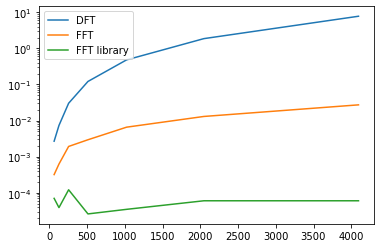

In [8]:
plt.plot(ns, tdft, label="DFT")
plt.plot(ns, tfft, label="FFT")
plt.plot(ns, tfftlib, label="FFT library")
plt.legend()
plt.semilogy()
plt.show()

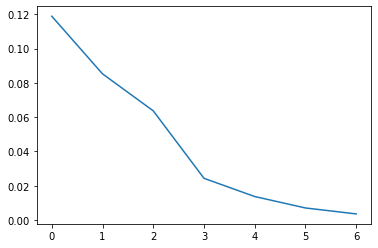

In [9]:
ratio = np.array(tfft) / np.array(tdft)
plt.plot(ratio)

## (6) たたみこみ

$h(n) = [\underline{1}, 5, 10, 10, 5, 1]$

$x(n) = [\underline{1}, 2, 0, -2, 3, -2]$

N=6

(a) 線形たたみこみ

\begin{align}
y(0) &= \Sigma_{k=0}^{N-1}h(k)x(0-k) = 1\\
y(1) &= \Sigma_{k=0}^{N-1}h(k)x(1-k) = 2+5 = 7\\
y(2) &= \Sigma_{k=0}^{N-1}h(k)x(2-k) = 0+10+10 = 20\\
y(3) &= \Sigma_{k=0}^{N-1}h(k)x(3-k) = -2+0+20+10 = 28\\
y(4) &= \Sigma_{k=0}^{N-1}h(k)x(4-k) = 3-10+0+20+5 = 18\\
y(5) &= \Sigma_{k=0}^{N-1}h(k)x(5-k) = -2+15-20+0+10+1 = 4\\
y(6) &= \Sigma_{k=0}^{N-1}h(k)x(6-k) = 0-10+30-20+0+2 = 2\\
y(7) &= \Sigma_{k=0}^{N-1}h(k)x(7-k) = 0+0-20+30-10+0 = 0\\
y(8) &= \Sigma_{k=0}^{N-1}h(k)x(8-k) = 0+0+0-20+15-2 = -7\\
y(9) &= \Sigma_{k=0}^{N-1}h(k)x(9-k) = 0+0+0+0-10+3 = -7\\
y(10) &= \Sigma_{k=0}^{N-1}h(k)x(10-k) = 0+0+0+0+0-2 = -2\\
\end{align}

$y(n)=[\underline{1}, 7, 20, 28, 18, 3, 2, 0, -7, 7, -2]$



(b) 循環たたみこみ

円を書いて計算する．

$y_{c}(n)=[\underline{3}, 7, 13, 21, 16, 4]$

(c) 循環たたみこみによる線形たたみこみ

In [15]:
hn = [1.0, 5.0, 10.0, 10.0, 5.0, 1.0]
xn = [1.0, 2.0, 0.0, -2.0, 3.0, -2.0]
N = len(hn)
M = 2 * N - 1
pad = [0 for i in range(M-N)]
len(pad)

hnp = np.array(hn + pad)
xnp = np.array(xn + pad)

def circular_convolution(h, x):
    y = np.zeros_like(x)
    N = x.size
    for n in range(N):
        t = 0.0
        for k in range(N):
            t += h[k] * x[n-k]
        y[n] = t
    return y

y = circular_convolution(hnp, xnp)
print(y)

[ 1.  7. 20. 28. 18.  4.  2.  0. -7. -7. -2.]


FFTを使う方法

In [20]:
Hp = np.fft.fft(hnp)
Xp = np.fft.fft(xnp)
Y = Hp * Xp
y2 = np.fft.ifft(Y)
y2

array([ 1.00000000e+00+0.j,  7.00000000e+00+0.j,  2.00000000e+01+0.j,
        2.80000000e+01+0.j,  1.80000000e+01+0.j,  4.00000000e+00+0.j,
        2.00000000e+00+0.j,  3.87568765e-15+0.j, -7.00000000e+00+0.j,
       -7.00000000e+00+0.j, -2.00000000e+00+0.j])

## (7) 周波数間引きFFT

参考：寒川他，HPCプログラミング，オーム社，2009.

時間間引きとの比較
- FFT流れ図：時間間引きと入力と出力が逆方向になっている．
- ビット逆順：入力側は自然数の順序で，出力側がビット逆順になっている．
- バタフライ：Wが梯子のはしごの右側に移った形．  
$X_{s+1}(q) = X_{s}(q) + X_{s}(r)$  
$X_{s+1}(r) = (X_{s}(q) - X_{s}(r))W_{N}^{k}$

- 計算量：同じ．